# Loan Default Prediction

This notebook analyzes Lending Club loan data and builds machine learning models to predict loan default risk.

Steps covered:
- Data understanding
- Data cleaning
- Feature engineering
- Model building (Logistic Regression, Decision Tree, Random Forest)
- Evaluation using Precision, Recall, F1-score and ROC-AUC

In [7]:
import pandas as pd
import numpy as np
import os
os.listdir('/kaggle/input')

['datasets']

In [8]:
os.listdir('/kaggle/input/datasets')

['wordsforthewise']

In [9]:
os.listdir('/kaggle/input/datasets/wordsforthewise')

['lending-club']

In [10]:
os.listdir('/kaggle/input/datasets/wordsforthewise/lending-club')

['rejected_2007_to_2018Q4.csv.gz',
 'accepted_2007_to_2018Q4.csv.gz',
 'accepted_2007_to_2018q4.csv',
 'rejected_2007_to_2018q4.csv']

In [11]:
df = pd.read_csv(
    "/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz",
    nrows=200000
)

/tmp/ipykernel_57/1193496916.py:1: DtypeWarning: Columns (19,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [12]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
print(f"Number of Records: {df.shape[0]:,.0f}")
print(f"Number of Features: {df.shape[1]}")

Number of Records: 200,000
Number of Features: 151


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 230.4+ MB


In [15]:
df.isnull().sum()

id                            0
member_id                200000
loan_amnt                     0
funded_amnt                   0
funded_amnt_inv               0
                          ...  
settlement_status        194160
settlement_date          194160
settlement_amount        194160
settlement_percentage    194160
settlement_term          194160
Length: 151, dtype: int64

In [16]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,2.000000e+05,0.0,200000.000000,200000.000000,200000.000000,200000.000000,200000.00000,2.000000e+05,199998.000000,200000.000000,...,1409.0,1409.000000,1409.0,1409.000000,1127.000000,1409.000000,1409.000000,5840.000000,5840.000000,5840.000000
mean,6.229632e+07,NaN,15278.155750,15278.155750,15269.511596,12.361763,441.38414,7.815081e+04,19.164467,0.346435,...,3.0,126.486629,3.0,14.205820,376.014091,10014.509659,186.061363,5015.406039,47.100265,13.485445
std,3.941141e+06,NaN,8651.134393,8651.134393,8646.320176,4.242099,247.05213,8.051362e+04,9.157581,0.915392,...,0.0,102.406308,0.0,9.748846,301.176324,6313.702334,181.204527,3557.532284,5.753855,7.537550
min,5.670500e+04,NaN,1000.000000,1000.000000,900.000000,5.320000,14.77000,0.000000e+00,0.000000,0.000000,...,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.020000,130.000000,20.000000,0.000000
25%,5.941173e+07,NaN,8500.000000,8500.000000,8475.000000,9.170000,261.88000,4.757550e+04,12.540000,0.000000,...,3.0,46.860000,3.0,7.000000,140.190000,4708.770000,44.950000,2192.490000,45.000000,8.000000
50%,6.221753e+07,NaN,14000.000000,14000.000000,14000.000000,12.290000,383.81000,6.500000e+04,18.610000,0.000000,...,3.0,99.590000,3.0,15.000000,296.610000,8879.160000,134.560000,4344.990000,45.000000,13.500000
75%,6.564457e+07,NaN,20000.000000,20000.000000,20000.000000,14.650000,580.73000,9.340000e+04,25.410000,0.000000,...,3.0,174.920000,3.0,23.000000,521.820000,14383.870000,275.290000,7000.000000,50.000000,18.000000
max,6.861706e+07,NaN,35000.000000,35000.000000,35000.000000,28.990000,1445.46000,9.000000e+06,999.000000,30.000000,...,3.0,638.130000,3.0,30.000000,1914.390000,29401.040000,927.790000,26242.500000,97.660000,65.000000


In [17]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

Categorising the features

In [18]:
id_columns = ['id','member_id']

target = 'loan_status'

numerical_features = df.select_dtypes(include=['int64','float64']).columns

categorical_features = df.select_dtypes(include=['object']).columns

Dropping ID columns as they have no predictive information

In [19]:
df.drop(columns=['id','member_id'], inplace=True)


In [20]:
# Checking if the ID columns have been removed
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


Dropping columns with too many missing values. Here, we are removing columns with almost 80% missing values by calculating percentage.

1. Checking the columns with null values
2. Dividing the number fo null values with the total number of rows in each column to find percentage
3. Creating a dataframe to show column, missing values and % in one table
4. Sorting values in descending order (ascending=False) to see which columns to eliminate first.

In [21]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
})

missing_table = missing_table.sort_values(by='Percentage (%)', ascending=False)
pd.set_option('display.max_rows', None) #Shows all 149 rows in a table

missing_table

,Missing Values,Percentage (%)
sec_app_open_act_il,200000,100.0000
sec_app_inq_last_6mths,200000,100.0000
sec_app_open_acc,200000,100.0000
sec_app_mort_acc,200000,100.0000
sec_app_mths_since_last_major_derog,200000,100.0000
sec_app_collections_12_mths_ex_med,200000,100.0000
sec_app_chargeoff_within_12_mths,200000,100.0000
sec_app_num_rev_accts,200000,100.0000
sec_app_earliest_cr_line,200000,100.0000
sec_app_revol_util,200000,100.0000


Removing/ Filling columns based on the following rules:
> 80% - Remove



In [22]:
cols_to_drop = missing_table[missing_table['Percentage (%)'] > 80].index # Selects columsn with > 80% missing and returns their names

df = df.drop(columns=cols_to_drop, errors='ignore') # Removes the columns from the dataset

In [23]:
print(cols_to_drop)

Index(['sec_app_open_act_il', 'sec_app_inq_last_6mths', 'sec_app_open_acc',
       'sec_app_mort_acc', 'sec_app_mths_since_last_major_derog',
       'sec_app_collections_12_mths_ex_med',
       'sec_app_chargeoff_within_12_mths', 'sec_app_num_rev_accts',
       'sec_app_earliest_cr_line', 'sec_app_revol_util',
       'sec_app_fico_range_high', 'sec_app_fico_range_low', 'revol_bal_joint',
       'desc', 'dti_joint', 'annual_inc_joint', 'verification_status_joint',
       'orig_projected_additional_accrued_interest', 'payment_plan_start_date',
       'hardship_type', 'hardship_reason', 'hardship_dpd', 'hardship_end_date',
       'hardship_length', 'hardship_status', 'hardship_amount',
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'hardship_loan_status', 'hardship_start_date', 'deferral_term',
       'settlement_amount', 'settlement_term', 'settlement_percentage',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'il_util'

In [24]:
print(df.columns)

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'fico_range_low', 'fico_range_high', 'inq_last_6mths',
       'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_b

In [25]:
df.shape

(200000, 96)

Filling numerical data less than 5% with the median value.

In [26]:
for col in numerical_features:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

Filling Categorical data with the mode

In [27]:
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode())

In [28]:
df.isnull().sum()


loan_amnt                             0
funded_amnt                           0
funded_amnt_inv                       0
term                                  0
int_rate                              0
installment                           0
grade                                 0
sub_grade                             0
emp_title                         12130
emp_length                        12103
home_ownership                        0
annual_inc                            0
verification_status                   0
issue_d                               0
loan_status                           0
pymnt_plan                            0
url                                   0
purpose                               0
title                               132
zip_code                              0
addr_state                            0
dti                                   0
delinq_2yrs                           0
earliest_cr_line                      0
fico_range_low                        0


The title column contains free-text descriptions of the loan purpose that largely duplicate information already captured in the purpose variable. Since it introduces high cardinality and limited additional predictive value, the column was removed.

In [29]:
df.drop(columns=['title'], inplace=True, errors='ignore')

Checking if the title column has been successfully dropped from the dataframe

In [30]:
'title' in df.columns

False

Dropping last payment as this can lead to data leakage

In [31]:
df.drop(columns=['last_pymnt_d'], inplace=True)

In [32]:
'last_pymnt_d ' in df.columns

False

Dropping 'emp_title' as it has thousands of unique values, isn't standardized and has weak predictive signal.

In [33]:
df.drop(columns=['emp_title'], inplace=True, errors='ignore')

In [34]:
'emp_title' in df.columns

False

Employment Length (emp_length) was retained because it captures employment stability, which can influence a borrower’s ability to repay a loan. Some missing values remained after the general imputation step because the column was not included in the earlier categorical imputation loop. Since the feature is meaningful for credit risk modelling, the remaining missing values were filled using the mode of the column.

In [35]:
# Checking different types of categories in the column
df['emp_length'].unique()

array(['10+ years', '3 years', '4 years', '6 years', '1 year', '7 years',
       '8 years', '5 years', '2 years', '9 years', '< 1 year', nan],
      dtype=object)

In [36]:
#Checking how many entries there are for each category in the column
df['emp_length'].value_counts(dropna=False)

emp_length
10+ years    67516
2 years      17529
< 1 year     16736
3 years      15851
1 year       13111
NaN          12103
5 years      11933
4 years      11449
8 years      10205
7 years       7893
9 years       7840
6 years       7834
Name: count, dtype: int64

Ensuring missing values are filled

In [37]:
df['emp_length'].fillna(df['emp_length'].mode()[0], inplace=True)

/tmp/ipykernel_57/746317378.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['emp_length'].fillna(df['emp_length'].mode()[0], inplace=True)


The emp_length feature was converted into a numeric representation (0–10 years) because it represents an ordered variable describing employment stability. Converting it into numerical form allows machine learning models to interpret the progression in employment duration more effectively.

In [38]:
#Checking to see if emp_length is a numeric column
df['emp_length'].dtype

dtype('O')

In [39]:
df['emp_length'].unique()

array(['10+ years', '3 years', '4 years', '6 years', '1 year', '7 years',
       '8 years', '5 years', '2 years', '9 years', '< 1 year'],
      dtype=object)

In [40]:
#Checking to see if there are no missing values
df['emp_length'].isnull().sum()

np.int64(0)

In [41]:
df.isnull().sum()

loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_length                        0
home_ownership                    0
annual_inc                        0
verification_status               0
issue_d                           0
loan_status                       0
pymnt_plan                        0
url                               0
purpose                           0
zip_code                          0
addr_state                        0
dti                               0
delinq_2yrs                       0
earliest_cr_line                  0
fico_range_low                    0
fico_range_high                   0
inq_last_6mths                    0
mths_since_last_delinq            0
open_acc                          0
pub_rec                     

last_credit_pull_d            

The last_credit_pull_d feature represents the most recent date when the borrower’s credit information was accessed. Since this event occurs after loan issuance, it may introduce data leakage when predicting default risk at the time of loan approval. Therefore, the column was removed from the dataset.

In [42]:
df.drop(columns=['last_credit_pull_d'], inplace=True)

In [43]:
df.isnull().sum()

loan_amnt                         0
funded_amnt                       0
funded_amnt_inv                   0
term                              0
int_rate                          0
installment                       0
grade                             0
sub_grade                         0
emp_length                        0
home_ownership                    0
annual_inc                        0
verification_status               0
issue_d                           0
loan_status                       0
pymnt_plan                        0
url                               0
purpose                           0
zip_code                          0
addr_state                        0
dti                               0
delinq_2yrs                       0
earliest_cr_line                  0
fico_range_low                    0
fico_range_high                   0
inq_last_6mths                    0
mths_since_last_delinq            0
open_acc                          0
pub_rec                     

In [44]:
df.drop(columns=['total_pymnt'], inplace=True)

In [45]:
'total_pymnt' in df.columns

False

In [46]:
df.drop(columns=['recoveries'], inplace=True)

In [47]:
'recoveries' in df.columns

False

In [48]:
df.drop(columns=['collection_recovery_fee'], inplace=True)

In [49]:
'collection_recovery_fee' in df.columns

False

**EXPLORATORY DATA ANALYSIS**

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

Encoding the target variable i.e. loan_status

In [51]:
df = df[df['loan_status'].isin(['Fully Paid','Charged Off'])]

df['loan_status'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

Applying IQR filtering to columns with extreme outliers.

In [52]:
columns_to_filter = [
    'dti',
    'annual_inc',
    'loan_amnt',
    'int_rate',
    'installment',
    'revol_bal',
    'revol_util'
]

for col in columns_to_filter:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [53]:
df['dti'].describe()

count    150904.000000
mean         18.829409
std           8.629656
min           0.000000
25%          12.290000
50%          18.240000
75%          24.970000
max          44.240000
Name: dti, dtype: float64

**Target Variable Analysis**

Helps identify class imbalance, which determines the choice of evaluation metrics and model strategy.

/tmp/ipykernel_57/599397566.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='viridis')


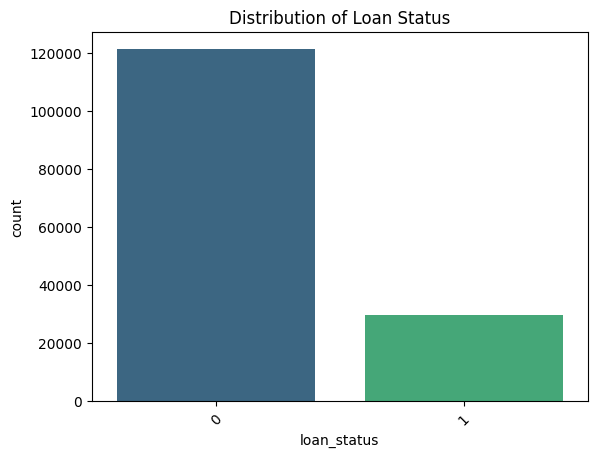

In [54]:
sns.countplot(x='loan_status', data=df, palette='viridis')
plt.title("Distribution of Loan Status")
plt.xticks(rotation=45)
plt.show()

Most loans in the dataset are **Fully Paid (~140k)**, while about **~35k loans are Charged Off**, indicating default. A smaller portion remains **Current (~23k)**, with very few loans in late or grace periods. This suggests a **clear class imbalance**, which is important to consider when training prediction models.



**Loan Amount Distribution**

Helps detect skewness and outliers, guiding transformations or scaling for better model performance.

/tmp/ipykernel_57/2062954399.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['loan_amnt'], bins=50, palette='Set2')


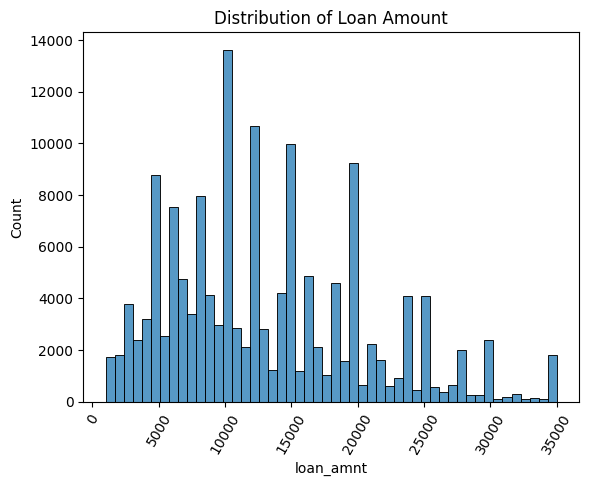

In [55]:
sns.histplot(df['loan_amnt'], bins=50, palette='Set2')
plt.title("Distribution of Loan Amount")
plt.xticks(rotation = 60)
plt.show()

Loan amounts range from about **USD 1000 to USD 35000**, with most loans concentrated between  **USD 5,000–USD 20,000**. Higher loan values appear less frequently, indicating a right-skewed distribution where smaller loans dominate the dataset.

**Distribution of Interest Rates**

Provides insight into borrower risk levels and ensures the feature is suitable for modelling.

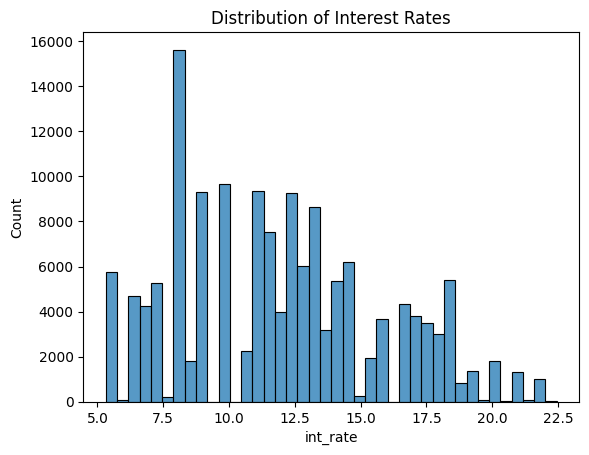

In [56]:
sns.histplot(df['int_rate'], bins=40)
plt.title("Distribution of Interest Rates")
plt.show()

Most loans are issued at interest rates between **8–15%,** with a peak around **10–12%**, suggesting a concentration of moderate-risk borrowers, while a long right tail indicates fewer high-risk loans with significantly higher interest rates.

**Interest Rate vs Default**

Identifies whether interest rate is a strong predictor of default for the model.

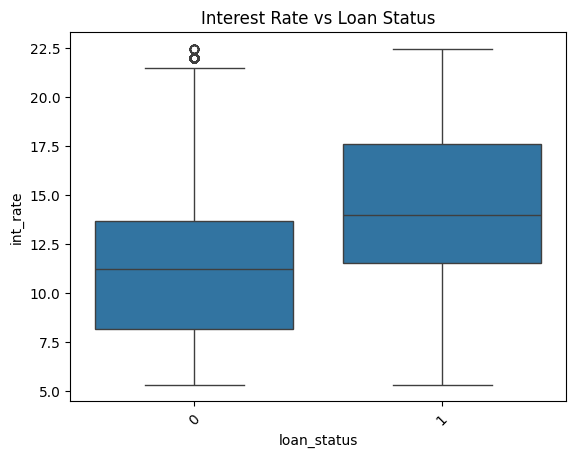

In [57]:
sns.boxplot(x='loan_status', y='int_rate', data=df)
plt.title("Interest Rate vs Loan Status")
plt.xticks(rotation =45)
plt.show()

Loans that are charged off or in late stages tend to have higher median interest rates **(around 13–16%)** compared to fully paid loans **(around 10–12%)**, indicating that borrowers assigned higher interest rates are more likely to default or face repayment issues.

**Loan Grade vs Default**

Confirms the predictive power of credit grading, helping prioritize important categorical features.

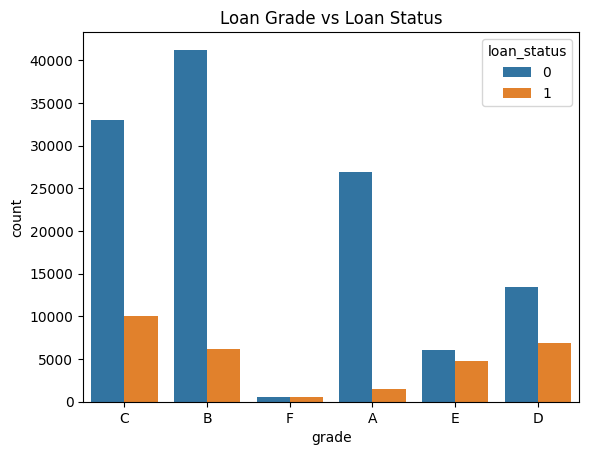

In [58]:
sns.countplot(x='grade', hue='loan_status', data=df)
plt.title("Loan Grade vs Loan Status")
plt.show()

Lower credit grades (D–G) exhibit a higher relative proportion of defaults compared to higher grades (A–B), confirming that loan grade is a strong predictor of default risk.

**DTI vs Default**

Shows whether financial burden influences default, validating its inclusion in the model.

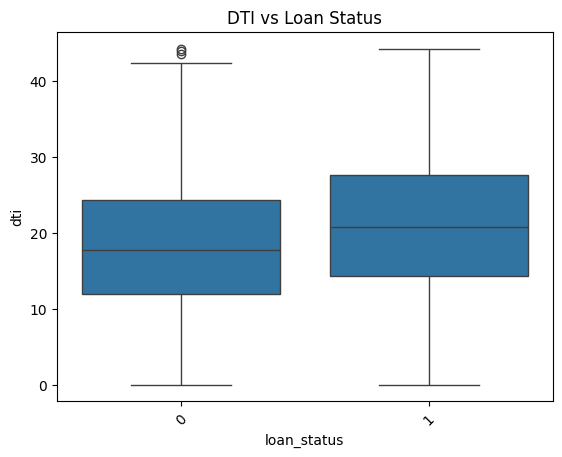

In [59]:
sns.boxplot(x='loan_status', y='dti', data=df)
plt.title("DTI vs Loan Status")
plt.xticks(rotation=45)
plt.show()

**Loan Purpose vs Default**

Helps understand category-level risk differences, informing encoding and feature engineering decisions.

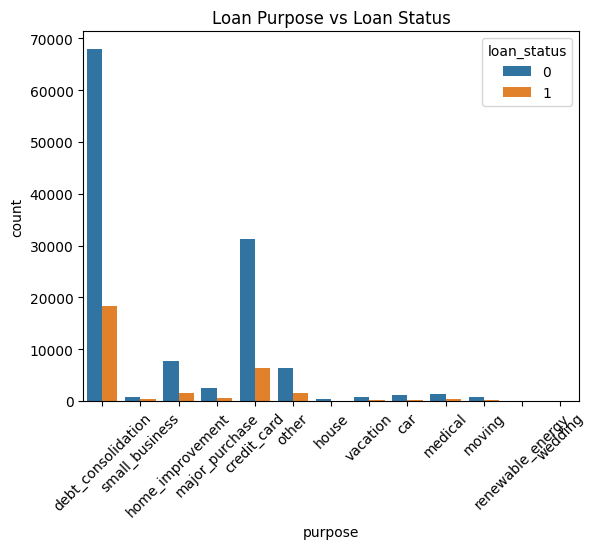

In [60]:
sns.countplot(x='purpose', hue='loan_status', data=df)
plt.xticks(rotation=45)
plt.title("Loan Purpose vs Loan Status")
plt.show()

Loans taken for debt consolidation and credit card purposes make up the largest share of both fully paid and charged-off loans, with a noticeable number of defaults, suggesting that these high-volume categories contribute significantly to overall default risk.

**Correlation Analysis**

Identifies relationships between features to avoid redundancy and improve model stability. We only use a few select columns that are important numeric predictors. Columns that were identical(total_rev_hi_lim highly correlated with total_bc_limit) or had no contribution in predicitng loan_status, were removed.

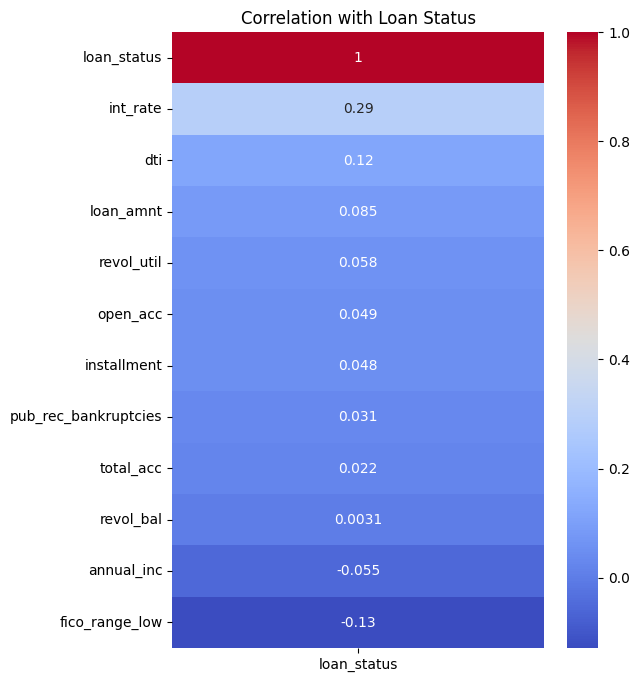

In [61]:
selected_cols = [
'dti',
'loan_amnt',
'int_rate',
'annual_inc',
'installment',
'fico_range_low',
'revol_bal',
'revol_util',
'open_acc',
'total_acc',
'pub_rec_bankruptcies',
'loan_status'
]

corr_matrix = df[selected_cols].corr()[['loan_status']].sort_values(by='loan_status', ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation with Loan Status")
plt.show()

**LOGISTIC REGRESSION**

The dataset is imbalanced because the number of non-default loans is significantly higher than default loans. This can bias the model towards predicting the majority class. Therefore we use Stratified K-Fold cross validation to ensure each fold maintains the same proportion of default and non-defaulted loans.


In [62]:
#Downloading logistic regression function from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split as test_train_split 
from sklearn.model_selection import StratifiedKFold

Defining x (features) and y (target) variables.

In [63]:
# using the same columns that we did for correlation analysis
features = [
'dti',
'loan_amnt',
'int_rate',
'annual_inc',
'installment',
'fico_range_low',
'revol_bal',
'revol_util',
'open_acc',
'total_acc',
'pub_rec_bankruptcies'
]

X = df[features]
y = df['loan_status']

Stratified K-Fold

In [64]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

Model

In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000, class_weight = "balanced") #this tells the model to not ignore minority class

Evaluation Metrics

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [67]:
# store results
accuracy_lr = []
precision_lr = []
recall_lr = []
f1_lr = []


# stratified training loop
for train_index, test_index in skf.split(X, y): # divides dataset into 5 folds 

    X_train = X.iloc[train_index] #selects rows from X using the training indices
    X_test = X.iloc[test_index] # select rows used to evaluate model performance

    y_train = y.iloc[train_index] #selects the loan_status values corresponding to the training rows.
    y_test = y.iloc[test_index] #Actual loan_status values for the testing set.


    # train model
    model.fit(X_train, y_train)


    # predictions
    y_pred = model.predict(X_test)


    # evaluation
    accuracy_lr.append(accuracy_score(y_test, y_pred))
    precision_lr.append(precision_score(y_test, y_pred))
    recall_lr.append(recall_score(y_test, y_pred))
    f1_lr.append(f1_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Generating a Confusion Matrix

In [68]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[16502  7713]
 [ 2088  3877]]


Understanding the Confusion Matrix

- True Negatives (bottom right): Correctly predicted borrowers who did not default.
- True Positives (top left): Correctly predicted borrowers who defaulted.
- False Positives (bottom left): Non-defaulters incorrectly classified as defaulters.
- False Negatives (top right): Actual defaulters that the model failed to identify.



In [69]:
# results
print("Accuracy for each fold:", accuracy_lr)
print("Average accuracy:", sum(accuracy_lr)/len(accuracy_lr))

print("\nAverage Precision:", sum(precision_lr)/len(precision_lr))
print("Average Recall:", sum(recall_lr)/len(recall_lr))
print("Average F1-score:", sum(f1_lr)/len(f1_lr))

Accuracy for each fold: [0.6765514727808887, 0.6718796593883569, 0.6710513236804612, 0.6769159404923627, 0.675248508946322]
Average accuracy: 0.6743293810576783

Average Precision: 0.3324114834986602
Average Recall: 0.6424476110645432
Average F1-score: 0.4381232691314544


Displaying a classificartion report

In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.68      0.77     24215
           1       0.33      0.65      0.44      5965

    accuracy                           0.68     30180
   macro avg       0.61      0.67      0.61     30180
weighted avg       0.78      0.68      0.71     30180



The Logistic Regression model achieved an overall accuracy of **67%**. For non-default borrowers (Class 0), the model performed well, achieving a precision of **89%**, recall of **68%**, and an F1-score of **77%**. For default borrowers (Class 1), the model achieved a precision of **33%**, recall of **65%**, and an F1-score of **44%**. The relatively high recall for the default class indicates that the model successfully identifies many borrowers who are likely to default, although the lower precision suggests that a considerable number of non-defaulters are incorrectly classified as defaulters. 

**Logistic Regression was used as the baseline model because it is simple, interpretable, and widely used for binary classification problems such as loan default prediction. While it achieved a moderate accuracy of 67%, its low precision (33.29%) and F1-score (43%) suggest that it struggles to accurately identify default cases. A key limitation of Logistic Regression is its assumption of a linear relationship between the predictors and the target variable, which may not capture the complex patterns present in financial data. To address this, we next explore a Decision Tree model, which can learn non-linear relationships and more complex decision rules from the data.**

**DECISION TREE**

In [71]:
# Import Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

Creating the Model

In [72]:
# Create a Decision Tree classifier
dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)
# random_state= 42 ensures reproducible results

Train the Model
* At this stage the model will learn
  
  Credit Score < ?
  
  Income < ?

  Loan Amount < ?

  and create decisions automatically
  


In [73]:
# Train the model using the training data
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=50, random_state=42)

Making predictions

In [74]:
# Predict loan default on the test set
y_pred_dt = dt_model.predict(X_test)

Generating the Confusion Matrix

In [75]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[14949  9266]
 [ 1753  4212]]


Understanding the Confusion Matrix:


* True Negatives (bottom right): Correctly identified borrowers who did not default.
* True Positives (top left): Correctly identified borrowers who did default.
* False Positives (bottom left): Non-defaulters incorrectly classified as defaulters.
* False Negatives (top right): Actual defaulters that the model failed to identify.



**Comparing Confusion Matrix of Decision Tree with Confusion Matrix of Logistic Regression**:
The Decision Tree produced a different confusion matrix because it learns non-linear decision rules, unlike Logistic Regression which assumes a linear relationship between variables and loan default.


Calculating Evaluation Metrics:


In [76]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Calculate model performance metrics

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.6348906560636183
Precision: 0.31250927437305237
Recall   : 0.7061190276613579
F1 Score : 0.4332664712235766


Displaying a Classification Report

In [77]:
from sklearn.metrics import classification_report

# Detailed evaluation report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.90      0.62      0.73     24215
           1       0.31      0.71      0.43      5965

    accuracy                           0.63     30180
   macro avg       0.60      0.66      0.58     30180
weighted avg       0.78      0.63      0.67     30180



The Decision Tree model achieved an overall accuracy of **71%**, showing good performance in identifying non-defaulters (F1-score = 0.81). However, its ability to detect actual loan defaults remains limited, with a precision of **28%**, recall of **31%**, and F1-score of **0.29** for the default class. This suggests that while the model performs reasonably well overall, it struggles to reliably identify high-risk borrowers.

Visualising the Tree

In [78]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

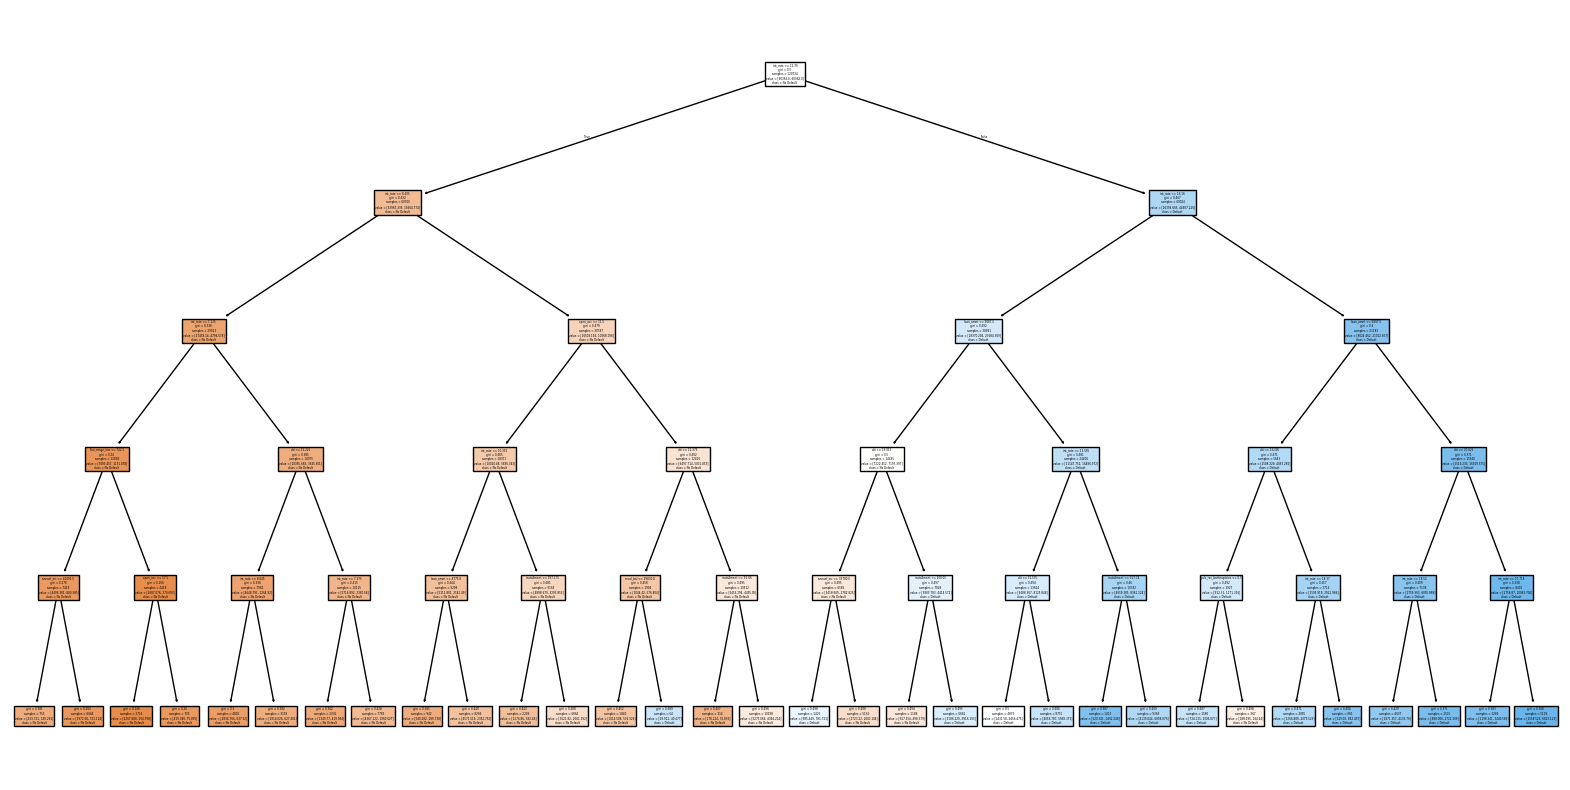

In [79]:
# Plot the decision tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=['No Default','Default']
)

plt.show()

Overfitting occurs when a machine learning model learns the training data too closely, including noise and random patterns, rather than the underlying relationships. As a result, the model performs very well on training data but poorly on unseen data. Preventing overfitting is important because the goal of a predictive model is to generalise well to new observations and provide reliable predictions. To improve readability and reduce overfitting, the tree depth was limited, allowing only the most important decision rules to be visualised.

In [80]:
# Decision Tree with depth control

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

**A comparison table between the evaluation metrics of Logistic Regression and Decision Tree model.**

In [81]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree'],
    'Accuracy':[accuracy_lr, accuracy_dt],
    'Precision':[precision_lr, precision_dt],
    'Recall':[recall_lr, recall_dt],
    'F1 Score':[f1_lr, f1_dt]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,"[0.6765514727808887, 0.6718796593883569, 0.671...","[0.332863808433841, 0.32984790874524716, 0.328...","[0.6338642078792959, 0.6398994132439229, 0.634...","[0.4365042715308243, 0.43530820550835375, 0.43..."
1,Decision Tree,0.634891,0.312509,0.706119,0.433266


**RANDOM FOREST (Bagging)**

In [82]:
# Importing libraries
from sklearn.ensemble import RandomForestClassifier

In [83]:
#Creating model
rf_model = RandomForestClassifier(
    class_weight="balanced"
    n_estimators=100, #builds 100 deicision trees
    random_state=42, # ensures reproducible results
    n_jobs=-1 #uses all CPU cores to train faster
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2239450384.py, line 3)

In [ ]:
#Train model
rf_model.fit(X_train, y_train)

In [ ]:
#Predict
y_pred_rf = rf_model.predict(X_test)

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

- True Negatives (bottom right): Correctly identified borrowers who did not default.
- True Positives (top left): Correctly identified borrowers who did default.
- False Positives (bottom left): Non-defaulters incorrectly classified as defaulters.
- False Negatives (top right): Actual defaulters that the model failed to identify.

**Key Observation:** The Random Forest model correctly identifies most non-defaulters but misses a large number of actual defaulters, resulting in many false negatives.

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

In [ ]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

The Random Forest model achieved an overall accuracy of **80.4%**, showing strong performance in identifying non-defaulters (F1-score = **0.89**). However, its ability to detect loan defaults is poor, with a precision of **52.7%**, recall of **10.4%**, and F1-score of **0.17** for the default class. Although the model has the highest overall accuracy, its very low recall indicates that it fails to identify most high-risk borrowers, making it less suitable for loan default prediction.

**Feature Importance**

Since a Random Forest is made up of many Decision Trees, it is not practical to interpret each tree individually. Instead, feature importance is calculated **after** the model has been trained to identify which variables contributed most to its predictions. This provides a simple and interpretable summary of how the Random Forest made its decisions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()

plt.show()

Random Forest calculates an importance score for every feature and then normalises them so they add up to 1.
Here, the **interest rate** has the greatest influence on the Random Forest's predictions. 

**XGBoost (Boosting)**

XGBoost is an ensemble learning algorithm that uses **boosting**, where multiple Decision Trees are built sequentially. Each new tree focuses on correcting the mistakes made by the previous trees, resulting in a more accurate and robust model. This makes XGBoost well-suited for loan default prediction, as it can learn complex patterns in borrower behaviour and improve the identification of high-risk borrowers that simpler models may miss.

In [ ]:
# Import Libraries
from xgboost import XGBClassifier

In [ ]:
# Create XGBoost classifier
xgb_model = XGBClassifier(
    scale_pos_weight=4,
    n_estimators=100,      # Number of trees
    learning_rate=0.1,     # Controls how quickly the model learns
    max_depth=5,           # Maximum depth of each tree
    random_state=42,
    eval_metric='logloss' #tells the algorithm how to evaluate itself while training and avoids warning messages.
)

In [ ]:
# Train the model
xgb_model.fit(X_train, y_train)

In [ ]:
# Predict loan defaults
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
# Generate confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

- True Negatives (bottom right): Correctly identified borrowers who did not default.
- True Positives (top left): Correctly identified borrowers who did default.
- False Positives (bottom left): Non-defaulters incorrectly classified as defaulters.
- False Negatives (top right): Actual defaulters that the model failed to identify.

Key Observation: The XGBoost classifier accurately identifies most non-default cases but struggles to detect default cases, resulting in a high number of false negatives. This indicates strong performance on the majority class but limited effectiveness in identifying the minority class.

In [ ]:
# Display classification report
print(classification_report(y_test, y_pred_xgb))

In [ ]:
#Store results
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Store feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

The XGBoost feature importance plot shows that **interest rate (`int_rate`)** is by far the most influential feature in predicting loan defaults, while other financial and credit-related variables provide additional supporting information.

# NEW APPROACH

In [ ]:
#Imports
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

**EVALUATION FUNCTION**

To ensure a fair comparison, all models are evaluated using the same **Stratified 5-Fold Cross-Validation** process. Instead of repeating the evaluation code for each model, a reusable evaluation function is created. This function trains and tests each model using identical data splits, calculates the average **Accuracy, Precision, Recall, and F1-score**, and generates a confusion matrix and classification report. Using a single evaluation function makes the code more efficient, consistent, and reliable while ensuring that all models are assessed under the same conditions.

In [ ]:
#Evaluation function
def evaluate_model(model, X, y): #creating a function

    # Create Stratified K-Fold object
    skf = StratifiedKFold( #keeps the same proprotion of 
        n_splits=5, #splits the dataset into 5 folds
        shuffle=True,
        random_state=42
    )

    # Store evaluation metrics by creating empty lists
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    # Store predictions from every fold
    all_y_true = []
    all_y_pred = [] #lists exist so that predictions from all five folds are saved and combined

    # Perform Stratified K-Fold Cross Validation
    for train_index, test_index in skf.split(X, y): #repeats the loop 5 times, splitting each into training indices and testing indices
        

        # Split data
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        # Train model
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)

        # Store predictions
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        # Calculate evaluation metrics
        accuracy_scores.append(
            accuracy_score(y_test, y_pred)
        )

        precision_scores.append(
            precision_score(y_test, y_pred)
        )

        recall_scores.append(
            recall_score(y_test, y_pred)
        )

        f1_scores.append(
            f1_score(y_test, y_pred)
        )

    # Print average performance
    print("Average Accuracy :", np.mean(accuracy_scores))
    print("Average Precision:", np.mean(precision_scores))
    print("Average Recall   :", np.mean(recall_scores))
    print("Average F1 Score :", np.mean(f1_scores))

    # Print confusion matrix
    print("\nConfusion Matrix")
    print(confusion_matrix(all_y_true, all_y_pred))

    # Print classification report
    print("\nClassification Report")
    print(classification_report(all_y_true, all_y_pred))

    # Return results for comparison table
    return {
        "Accuracy": np.mean(accuracy_scores),
        "Precision": np.mean(precision_scores),
        "Recall": np.mean(recall_scores),
        "F1": np.mean(f1_scores)
    }

**LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_results = evaluate_model( #runs the evaluate model
    lr_model,
    X, #function uses X to train the model
    y  #target variable
)

**DECISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

dt_results = evaluate_model(
    dt_model,
    X,
    y
)

**RANDOM FOREST**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    rf_model,
    X,
    y
)

**XGBoost**

In [ ]:
#Calculating the imbalance ratio
non_defaults = (y == 0).sum()
defaults = (y == 1).sum()

scale_pos_weight = non_defaults / defaults

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    n_estimators=100,

    learning_rate=0.1,

    max_depth=5,

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    eval_metric="logloss"

)

xgb_results = evaluate_model(
    xgb_model,
    X,
    y
)

In [ ]:
import pandas as pd

results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        lr_results["Accuracy"],
        dt_results["Accuracy"],
        rf_results["Accuracy"],
        xgb_results["Accuracy"]
    ],

    "Precision":[
        lr_results["Precision"],
        dt_results["Precision"],
        rf_results["Precision"],
        xgb_results["Precision"]
    ],

    "Recall":[
        lr_results["Recall"],
        dt_results["Recall"],
        rf_results["Recall"],
        xgb_results["Recall"]
    ],

    "F1 Score":[
        lr_results["F1"],
        dt_results["F1"],
        rf_results["F1"],
        xgb_results["F1"]
    ]

})

results

**Hyperparameter Tuning**

The initial models were trained using predefined hyperparameters. To improve their predictive performance, **GridSearchCV** is used to systematically test different combinations of hyperparameters. Each combination is evaluated using the same **5-Fold Stratified Cross-Validation** strategy, with the **F1-score** used as the optimisation metric. This ensures that the selected model provides the best balance between precision and recall for identifying loan defaults.

In [ ]:
from sklearn.model_selection import GridSearchCV

For random forest

In [ ]:
rf_params = {

    "n_estimators": [100, 200, 300],

    "max_depth": [5, 10, 15],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [20, 50, 100]

}

In [ ]:
rf_grid = GridSearchCV(

    estimator=rf_model,

    param_grid=rf_params,

    cv=skf,

    scoring="f1",

    n_jobs=-1

)

In [ ]:
rf_grid.fit(X, y)

In [ ]:
print("Best Parameters:")
print(rf_grid.best_params_)

In [ ]:
print("Best F1 Score:")
print(rf_grid.best_score_)

In [ ]:
best_rf = rf_grid.best_estimator_

In [ ]:
best_rf_results = evaluate_model(

    best_rf,

    X,

    y

)

For XG Boost

In [ ]:
xgb_params = {

    "n_estimators":[100,200,300],

    "max_depth":[3,5,7],

    "learning_rate":[0.01,0.05,0.1]

}

In [ ]:
xgb_grid = GridSearchCV(

    estimator=xgb_model,

    param_grid=xgb_params,

    cv=skf,

    scoring="f1",

    n_jobs=-1

)

In [ ]:
xgb_grid.fit(X,y)

In [ ]:
print(xgb_grid.best_params_)

In [ ]:
print(xgb_grid.best_score_)

In [ ]:
best_xgb = xgb_grid.best_estimator_

In [ ]:
best_xgb_results = evaluate_model(

    best_xgb,

    X,

    y

)

In [ ]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "Random Forest (Tuned)",

        "XGBoost",

        "XGBoost (Tuned)"

    ],

    "Accuracy":[

        lr_results["Accuracy"],

        dt_results["Accuracy"],

        rf_results["Accuracy"],

        best_rf_results["Accuracy"],

        xgb_results["Accuracy"],

        best_xgb_results["Accuracy"]

    ],

    "Precision":[

        lr_results["Precision"],

        dt_results["Precision"],

        rf_results["Precision"],

        best_rf_results["Precision"],

        xgb_results["Precision"],

        best_xgb_results["Precision"]

    ],

    "Recall":[

        lr_results["Recall"],

        dt_results["Recall"],

        rf_results["Recall"],

        best_rf_results["Recall"],

        xgb_results["Recall"],

        best_xgb_results["Recall"]

    ],

    "F1 Score":[

        lr_results["F1"],

        dt_results["F1"],

        rf_results["F1"],

        best_rf_results["F1"],

        xgb_results["F1"],

        best_xgb_results["F1"]

    ]

})

results